In [1]:
from __future__ import print_function
import os
import sys
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns
import datetime
import scipy as sp

This hourly data set contains the PM2.5 data of US Embassy in Beijing. Meanwhile, meteorological data from Beijing Capital International Airport are also included.

In [2]:
#set current working directory
#os.chdir('/Users/sergiocalderon/Documents/Documentos - iMac de Sergio/Documentos iMac Sergio/Cursos/Time Series')
#Read the dataset into a pandas.DataFrame
df = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

In [3]:
print(df)
print(type(df))

          No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd     Iws  \
0          1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW    1.79   
1          2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW    4.92   
2          3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW    6.71   
3          4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW    9.84   
4          5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW   12.97   
...      ...   ...    ...  ...   ...    ...   ...   ...     ...  ...     ...   
43819  43820  2014     12   31    19    8.0   -23  -2.0  1034.0   NW  231.97   
43820  43821  2014     12   31    20   10.0   -22  -3.0  1034.0   NW  237.78   
43821  43822  2014     12   31    21   10.0   -22  -3.0  1034.0   NW  242.70   
43822  43823  2014     12   31    22    8.0   -22  -4.0  1034.0   NW  246.72   
43823  43824  2014     12   31    23   12.0   -21  -3.0  1034.0   NW  249.85   

       Is  Ir  
0       0   0  
1      

En seguida se crea una columna de fechas

In [4]:
df['datetime'] = df[['year', 'month', 'day', 'hour']].apply(lambda row: datetime.datetime(year=row['year'],
month=row['month'], day=row['day'],
hour=row['hour']), axis=1)
df.sort_values('datetime', ascending=True, inplace=True)

In [5]:
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0,2014-12-31 19:00:00
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0,2014-12-31 20:00:00
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0,2014-12-31 21:00:00
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0,2014-12-31 22:00:00


Text(0.5, 1.0, 'Box plot of Air Pressure')

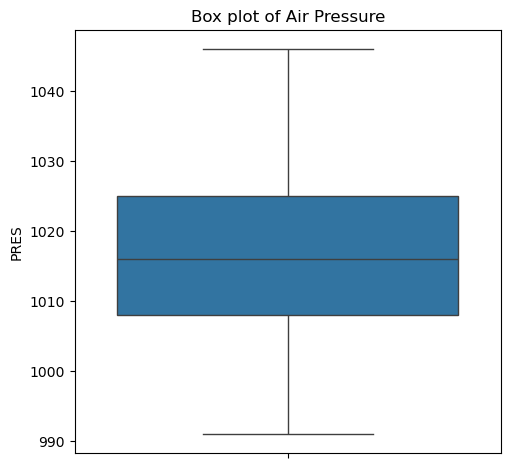

In [6]:
plt.figure(figsize=(5.5, 5.5))
g = sns.boxplot(df['PRES']) 
g.set_title('Box plot of Air Pressure')

Text(0.5, 1.0, 'Time series of Air Pressure')

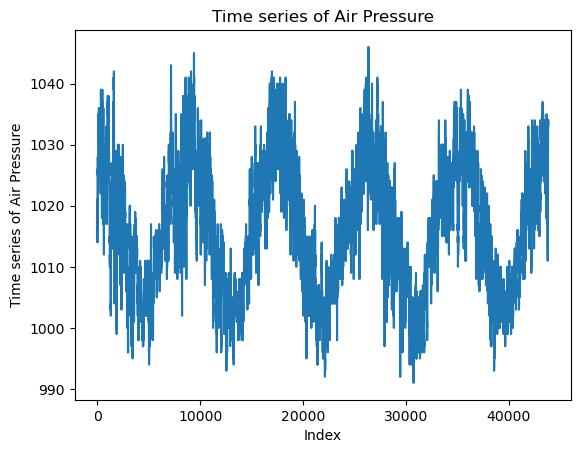

In [7]:
g = plt.plot(df['PRES'])
plt.xlabel('Index') 
plt.ylabel('Time series of Air Pressure') 
plt.title(label='Time series of Air Pressure') 

In [8]:
indice=df['datetime']
PRESdf =pd.DataFrame(df['PRES'].values,index=indice)


In [9]:
PRESdf.head(10)
type(PRESdf)

pandas.core.frame.DataFrame

In [10]:
PRESdf

,0
datetime,
2010-01-01 00:00:00,1021.0
2010-01-01 01:00:00,1020.0
2010-01-01 02:00:00,1019.0
2010-01-01 03:00:00,1019.0
2010-01-01 04:00:00,1018.0
...,...
2014-12-31 19:00:00,1034.0
2014-12-31 20:00:00,1034.0
2014-12-31 21:00:00,1034.0


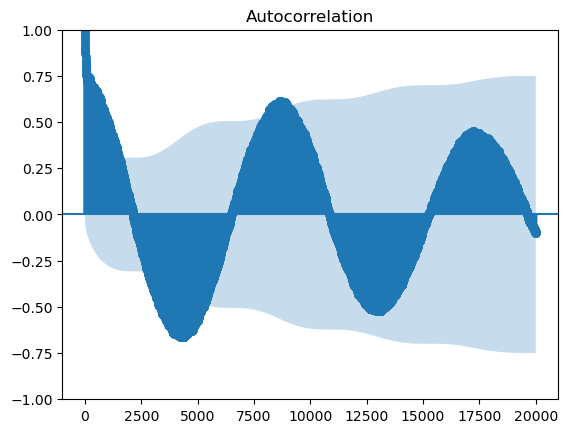

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
plot_acf(PRESdf,lags=20000)
plt.show()

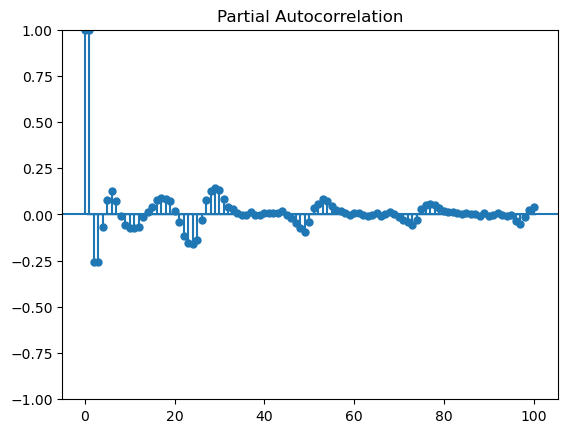

In [12]:
plot_pacf(PRESdf,lags=100,method='ldbiased')
plt.show()

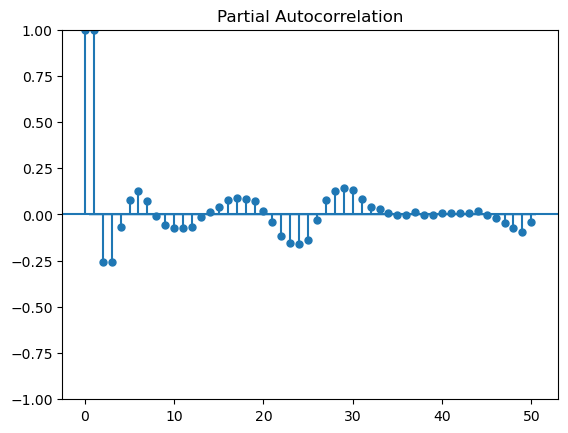

In [13]:
plot_pacf(PRESdf,lags=50,method='ldbiased')
plt.show()

5
0.00011409273457466229
8764.8


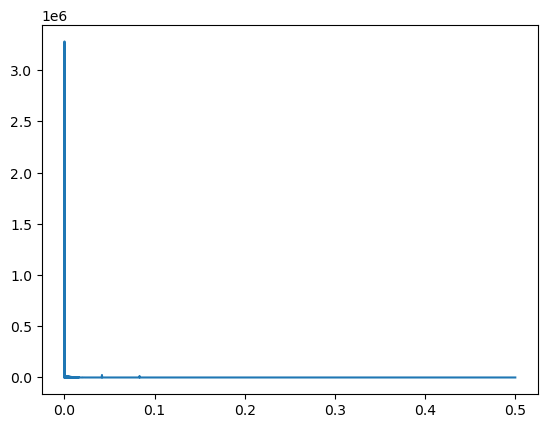

In [14]:
f, Pxx_den=sp.signal.periodogram(df['PRES'])
plt.plot(f, Pxx_den)
#plt.axvline(x=1/50,color='red')
max_index_value = np.argmax(Pxx_den, axis=0)
print(max_index_value)
frecuencia_max=f[max_index_value]
print(frecuencia_max)
print(1/frecuencia_max)

Note que 8764.8/24=365.2 que corresponde a un ciclo anual, sin embargo no se ve el ciclo diario o semanal.

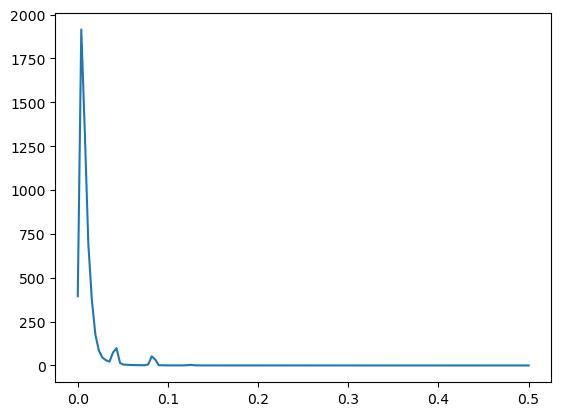

In [15]:
f_welch, Pxx_den_welch=sp.signal.welch(df['PRES'])
plt.plot(f_welch, Pxx_den_welch)


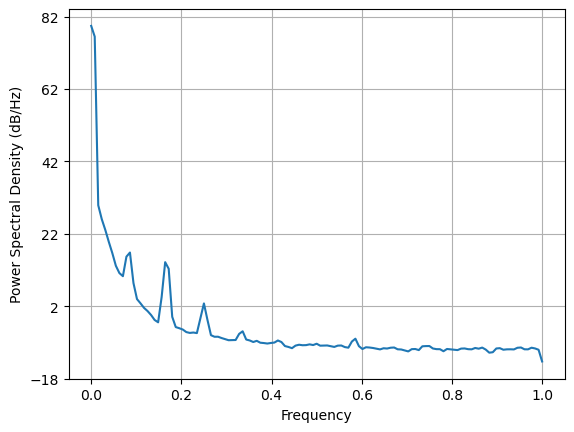

In [16]:
import matplotlib as mpl
Pxx, Freqs, lines=mpl.pyplot.psd(df['PRES'],return_line=True)

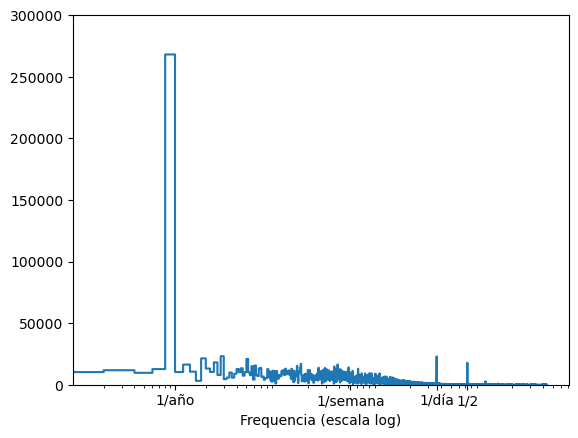

In [17]:
import tensorflow as tf
fft = tf.signal.rfft(df['PRES'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['PRES'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 300000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1,52.17891428571429 ,365.2524,365.2524*2], labels=['1/año', '1/semana','1/día','1/2'])
_ = plt.xlabel('Frequencia (escala log)')

Es importante señalar que dependiendo la hora del día, parece haber un valor medio distinto dependiendo del día. También parecer haber un comportamineto estacional de forma anual, es decir, el valor medio de la hora depende drel mes del año. 

 Adicionalmente podemos observar que el día de la semana no afecta el valor medio de la variable presión. Por lo tanto, se van a considerar solo dos componente, una para que tenga encuenta la hra del día y otro para que tenga en cuenta que el comportamiento anual, es decir, para que tenga en cuenta que al princiio del año el valor de la presión es mas lata y que al mediados es mas baja, mientras que en los meses intermedio el valor es fluctuante.

In [18]:
365.2524*24

8766.0576

In [19]:
#print(fft)
print(f_per_year)

[0.00000000e+00 2.00028697e-01 4.00057393e-01 ... 4.38262874e+03
 4.38282877e+03 4.38302880e+03]


Note que en este, caso la escala de la frecuencia está escalada para que sea leía por año.

In [20]:
date_time=df['datetime']
type(date_time)


pandas.core.series.Series

In [21]:
date_time.map(pd.Timestamp.timestamp) ###Convierte las fechas a float 

0        1.262304e+09
1        1.262308e+09
2        1.262311e+09
3        1.262315e+09
4        1.262318e+09
             ...     
43819    1.420052e+09
43820    1.420056e+09
43821    1.420060e+09
43822    1.420063e+09
43823    1.420067e+09
Name: datetime, Length: 43824, dtype: float64

#### Convertir las fechas en valores numéricos

Note que el tiempo va a ser convertido a segundos, por lo tanto debemos escribir los ciclos a segundos.

In [22]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)
timestamp_s

0        1.262304e+09
1        1.262308e+09
2        1.262311e+09
3        1.262315e+09
4        1.262318e+09
             ...     
43819    1.420052e+09
43820    1.420056e+09
43821    1.420060e+09
43822    1.420063e+09
43823    1.420067e+09
Name: datetime, Length: 43824, dtype: float64

In [23]:
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

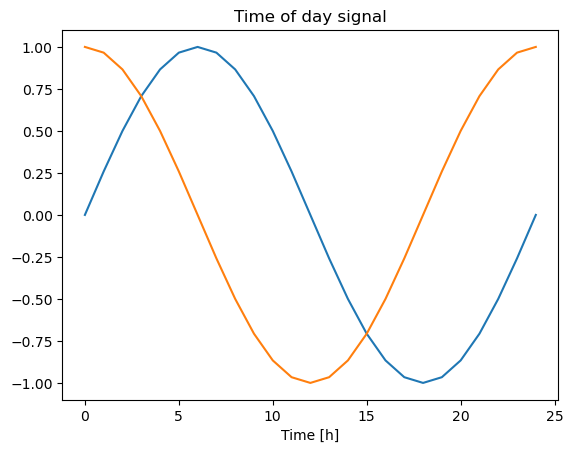

In [24]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

Text(0.5, 1.0, 'Time of year signal')

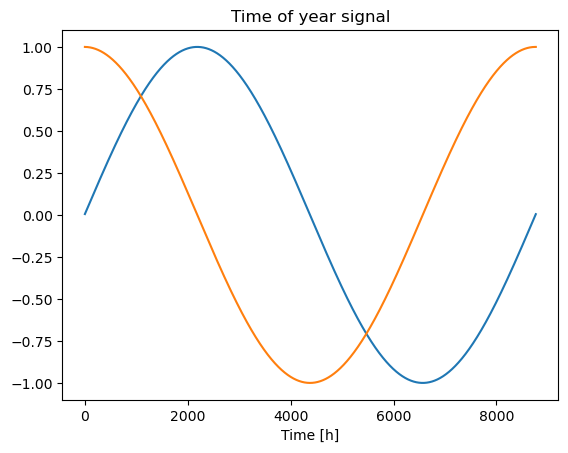

In [25]:
plt.plot(np.array(df['Year sin'])[:8766])
plt.plot(np.array(df['Year cos'])[:8766])
plt.xlabel('Time [h]')
plt.title('Time of year signal')

In [26]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir', 'datetime', 'Day sin', 'Day cos', 'Year sin',
       'Year cos'],
      dtype='object')

## Creación alternativa de covariables

In [27]:
indice=df['datetime']
PRESdf_alt =pd.DataFrame(df[['PRES','Day sin', 'Day cos', 'Year sin','Year cos','datetime']])


In [28]:
PRESdf_alt

,PRES,Day sin,Day cos,Year sin,Year cos,datetime
0,1021.0,-4.416858e-12,1.000000,0.005161,0.999987,2010-01-01 00:00:00
1,1020.0,2.588190e-01,0.965926,0.005878,0.999983,2010-01-01 01:00:00
2,1019.0,5.000000e-01,0.866025,0.006594,0.999978,2010-01-01 02:00:00
3,1019.0,7.071068e-01,0.707107,0.007311,0.999973,2010-01-01 03:00:00
4,1018.0,8.660254e-01,0.500000,0.008028,0.999968,2010-01-01 04:00:00
...,...,...,...,...,...,...
43819,1034.0,-9.659258e-01,0.258819,-0.002079,0.999998,2014-12-31 19:00:00
43820,1034.0,-8.660254e-01,0.500000,-0.001362,0.999999,2014-12-31 20:00:00
43821,1034.0,-7.071068e-01,0.707107,-0.000645,1.000000,2014-12-31 21:00:00
43822,1034.0,-5.000000e-01,0.866025,0.000072,1.000000,2014-12-31 22:00:00


In [29]:
indice

0       2010-01-01 00:00:00
1       2010-01-01 01:00:00
2       2010-01-01 02:00:00
3       2010-01-01 03:00:00
4       2010-01-01 04:00:00
                ...        
43819   2014-12-31 19:00:00
43820   2014-12-31 20:00:00
43821   2014-12-31 21:00:00
43822   2014-12-31 22:00:00
43823   2014-12-31 23:00:00
Name: datetime, Length: 43824, dtype: datetime64[ns]

In [30]:
PRES_alt_df = PRESdf_alt.set_index('datetime')

In [31]:
PRES_alt_df

,PRES,Day sin,Day cos,Year sin,Year cos
datetime,,,,,
2010-01-01 00:00:00,1021.0,-4.416858e-12,1.000000,0.005161,0.999987
2010-01-01 01:00:00,1020.0,2.588190e-01,0.965926,0.005878,0.999983
2010-01-01 02:00:00,1019.0,5.000000e-01,0.866025,0.006594,0.999978
2010-01-01 03:00:00,1019.0,7.071068e-01,0.707107,0.007311,0.999973
2010-01-01 04:00:00,1018.0,8.660254e-01,0.500000,0.008028,0.999968
...,...,...,...,...,...
2014-12-31 19:00:00,1034.0,-9.659258e-01,0.258819,-0.002079,0.999998
2014-12-31 20:00:00,1034.0,-8.660254e-01,0.500000,-0.001362,0.999999
2014-12-31 21:00:00,1034.0,-7.071068e-01,0.707107,-0.000645,1.000000


## Entrenamiento Validacion y Prueba

In [32]:
column_indices = {name: i for i, name in enumerate(PRES_alt_df.columns)}

n = len(PRES_alt_df)
train_dfPRES = PRES_alt_df[0:int(n*0.7)]
val_dfPRES = PRES_alt_df[int(n*0.7):int(n*0.9)]
test_dfPRES = PRES_alt_df[int(n*0.9):]

num_features = PRES_alt_df.shape[1]
num_features

5

In [33]:
train_dfPRES

,PRES,Day sin,Day cos,Year sin,Year cos
datetime,,,,,
2010-01-01 00:00:00,1021.0,-4.416858e-12,1.000000,0.005161,0.999987
2010-01-01 01:00:00,1020.0,2.588190e-01,0.965926,0.005878,0.999983
2010-01-01 02:00:00,1019.0,5.000000e-01,0.866025,0.006594,0.999978
2010-01-01 03:00:00,1019.0,7.071068e-01,0.707107,0.007311,0.999973
2010-01-01 04:00:00,1018.0,8.660254e-01,0.500000,0.008028,0.999968
...,...,...,...,...,...
2013-07-01 23:00:00,995.0,-2.588190e-01,0.965926,0.001555,-0.999999
2013-07-02 00:00:00,994.0,-1.150846e-11,1.000000,0.000839,-1.000000
2013-07-02 01:00:00,995.0,2.588190e-01,0.965926,0.000122,-1.000000


In [34]:
val_dfPRES

,PRES,Day sin,Day cos,Year sin,Year cos
datetime,,,,,
2013-07-02 04:00:00,994.0,0.866025,5.000000e-01,-0.002028,-0.999998
2013-07-02 05:00:00,994.0,0.965926,2.588190e-01,-0.002745,-0.999996
2013-07-02 06:00:00,994.0,1.000000,-4.801153e-13,-0.003462,-0.999994
2013-07-02 07:00:00,995.0,0.965926,-2.588190e-01,-0.004179,-0.999991
2013-07-02 08:00:00,996.0,0.866025,-5.000000e-01,-0.004896,-0.999988
...,...,...,...,...,...
2014-07-02 04:00:00,1003.0,0.866025,5.000000e-01,0.002143,-0.999998
2014-07-02 05:00:00,1003.0,0.965926,2.588190e-01,0.001426,-0.999999
2014-07-02 06:00:00,1004.0,1.000000,2.160132e-12,0.000710,-1.000000


In [35]:
test_dfPRES

,PRES,Day sin,Day cos,Year sin,Year cos
datetime,,,,,
2014-07-02 09:00:00,1004.0,7.071068e-01,-0.707107,-0.001441,-0.999999
2014-07-02 10:00:00,1004.0,5.000000e-01,-0.866025,-0.002158,-0.999998
2014-07-02 11:00:00,1004.0,2.588190e-01,-0.965926,-0.002874,-0.999996
2014-07-02 12:00:00,1003.0,4.723477e-12,-1.000000,-0.003591,-0.999994
2014-07-02 13:00:00,1003.0,-2.588190e-01,-0.965926,-0.004308,-0.999991
...,...,...,...,...,...
2014-12-31 19:00:00,1034.0,-9.659258e-01,0.258819,-0.002079,0.999998
2014-12-31 20:00:00,1034.0,-8.660254e-01,0.500000,-0.001362,0.999999
2014-12-31 21:00:00,1034.0,-7.071068e-01,0.707107,-0.000645,1.000000


## Normalización

In [36]:
train_mean = train_dfPRES.mean()
train_std = train_dfPRES.std()

train_df = (train_dfPRES - train_mean) / train_std
val_df = (val_dfPRES - train_mean) / train_std
test_df = (test_dfPRES - train_mean) / train_std

Note que se podría analizar que pasa cuando se tiene como variables predictoras solo a estas variables determinísticas, o como viene enseguida sólo con variables rezagadas. Finalmente, se pueden unir características de ambas y formar predictoras de las dos naturalezas.

## Creación de variables rezagadas

Note que vamos a enfocarnos en la predicción 1 paso adelante.

In [37]:
from pandas import DataFrame
# reframe as supervised learning
# lag observation (t-1) is the input variable and t is the output variable.
df1 = DataFrame()
print(df1)

Empty DataFrame
Columns: []
Index: []


In [38]:
for i in range(7,0,-1):
    df1[['t-'+str(i)]] = PRESdf.shift(i)

In [39]:
print(df1)

                        t-7     t-6     t-5     t-4     t-3     t-2     t-1
datetime                                                                   
2010-01-01 00:00:00     NaN     NaN     NaN     NaN     NaN     NaN     NaN
2010-01-01 01:00:00     NaN     NaN     NaN     NaN     NaN     NaN  1021.0
2010-01-01 02:00:00     NaN     NaN     NaN     NaN     NaN  1021.0  1020.0
2010-01-01 03:00:00     NaN     NaN     NaN     NaN  1021.0  1020.0  1019.0
2010-01-01 04:00:00     NaN     NaN     NaN  1021.0  1020.0  1019.0  1019.0
...                     ...     ...     ...     ...     ...     ...     ...
2014-12-31 19:00:00  1033.0  1032.0  1032.0  1032.0  1032.0  1033.0  1033.0
2014-12-31 20:00:00  1032.0  1032.0  1032.0  1032.0  1033.0  1033.0  1034.0
2014-12-31 21:00:00  1032.0  1032.0  1032.0  1033.0  1033.0  1034.0  1034.0
2014-12-31 22:00:00  1032.0  1032.0  1033.0  1033.0  1034.0  1034.0  1034.0
2014-12-31 23:00:00  1032.0  1033.0  1033.0  1034.0  1034.0  1034.0  1034.0

[43824 rows

In [40]:
# Create column t
df1['t'] = PRESdf.values
print(df1.head(8))

                        t-7     t-6     t-5     t-4     t-3     t-2     t-1  \
datetime                                                                      
2010-01-01 00:00:00     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2010-01-01 01:00:00     NaN     NaN     NaN     NaN     NaN     NaN  1021.0   
2010-01-01 02:00:00     NaN     NaN     NaN     NaN     NaN  1021.0  1020.0   
2010-01-01 03:00:00     NaN     NaN     NaN     NaN  1021.0  1020.0  1019.0   
2010-01-01 04:00:00     NaN     NaN     NaN  1021.0  1020.0  1019.0  1019.0   
2010-01-01 05:00:00     NaN     NaN  1021.0  1020.0  1019.0  1019.0  1018.0   
2010-01-01 06:00:00     NaN  1021.0  1020.0  1019.0  1019.0  1018.0  1017.0   
2010-01-01 07:00:00  1021.0  1020.0  1019.0  1019.0  1018.0  1017.0  1017.0   

                          t  
datetime                     
2010-01-01 00:00:00  1021.0  
2010-01-01 01:00:00  1020.0  
2010-01-01 02:00:00  1019.0  
2010-01-01 03:00:00  1019.0  
2010-01-01 04:00:00  1018.0  

In [41]:
# Create a new subsetted dataframe, removing Nans from first 7 rows
df1_PRES = df1[7:]
print(df1_PRES.head(7))
df1_PRES.shape

                        t-7     t-6     t-5     t-4     t-3     t-2     t-1  \
datetime                                                                      
2010-01-01 07:00:00  1021.0  1020.0  1019.0  1019.0  1018.0  1017.0  1017.0   
2010-01-01 08:00:00  1020.0  1019.0  1019.0  1018.0  1017.0  1017.0  1017.0   
2010-01-01 09:00:00  1019.0  1019.0  1018.0  1017.0  1017.0  1017.0  1017.0   
2010-01-01 10:00:00  1019.0  1018.0  1017.0  1017.0  1017.0  1017.0  1017.0   
2010-01-01 11:00:00  1018.0  1017.0  1017.0  1017.0  1017.0  1017.0  1017.0   
2010-01-01 12:00:00  1017.0  1017.0  1017.0  1017.0  1017.0  1017.0  1017.0   
2010-01-01 13:00:00  1017.0  1017.0  1017.0  1017.0  1017.0  1017.0  1015.0   

                          t  
datetime                     
2010-01-01 07:00:00  1017.0  
2010-01-01 08:00:00  1017.0  
2010-01-01 09:00:00  1017.0  
2010-01-01 10:00:00  1017.0  
2010-01-01 11:00:00  1017.0  
2010-01-01 12:00:00  1015.0  
2010-01-01 13:00:00  1015.0  


(43817, 8)

# Dividir los datos en repuestas y Covariables, entrenamiento, validación y prueba.

In [42]:
# Split data

PRESsplit = df1_PRES.values
# split into lagged variables and original time series
X1= PRESsplit[:, 0:-1]  # slice all rows and start with column 0 and go up to but not including the last column
y1 =PRESsplit[:,-1]  # slice all rows and last column, essentially separating out 't' column

In [43]:
print(X1)
print(y1)

[[1021. 1020. 1019. ... 1018. 1017. 1017.]
 [1020. 1019. 1019. ... 1017. 1017. 1017.]
 [1019. 1019. 1018. ... 1017. 1017. 1017.]
 ...
 [1032. 1032. 1032. ... 1033. 1034. 1034.]
 [1032. 1032. 1033. ... 1034. 1034. 1034.]
 [1032. 1033. 1033. ... 1034. 1034. 1034.]]
[1017. 1017. 1017. ... 1034. 1034. 1034.]


Primero dividiremos nuestro conjunto de datos en entrenamiento(90%) y prueba(10%), luego el entrenamiento será dividido en entrenamiento(80% del 90%) y validación(20% del 90%).

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [45]:
X_train_full, X_test, y_train_full, y_test=train_test_split(X1,y1,test_size=0.1, train_size=0.9,shuffle=False)

In [46]:
print(X_train_full.shape)
print(X_test.shape)

print(y_train_full.shape)
print(y_test.shape)

(39435, 7)
(4382, 7)
(39435,)
(4382,)


In [47]:
X_train, X_val, y_train, y_val=train_test_split(X_train_full,y_train_full,test_size=0.2, train_size=0.8,shuffle=False)

In [48]:
print(X_train.shape)
print(X_val.shape)

print(y_train.shape)
print(y_val.shape)

(31548, 7)
(7887, 7)
(31548,)
(7887,)


In [49]:
31548+7887+4382

43817

Vamos a chequear que los valores quedaron consecutivos

In [50]:
y_train

array([1017., 1017., 1017., ..., 1002., 1002., 1002.], shape=(31548,))

In [51]:
y_val

array([1001., 1000., 1002., ..., 1004., 1004., 1004.], shape=(7887,))

In [52]:
y_test

array([1004., 1004., 1003., ..., 1034., 1034., 1034.], shape=(4382,))

# Normalización de las covariables únicamente

Note que para éste caso se elige la normalización MinMaxScaler, es decir, transforma todas las variables a que tomen valores entre 0 y 1. Vale la pena decir que esta transformación es basada en el conjuto de entrenamiento, y aplicada con esos parámetros(Min y Max), a los tres conjuntos entrenamiento , validación y prueba.

In [53]:
scaler=MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

In [54]:
X_train

array([[0.54545455, 0.52727273, 0.50909091, ..., 0.49090909, 0.47272727,
        0.47272727],
       [0.52727273, 0.50909091, 0.50909091, ..., 0.47272727, 0.47272727,
        0.47272727],
       [0.50909091, 0.50909091, 0.49090909, ..., 0.47272727, 0.47272727,
        0.47272727],
       ...,
       [0.21818182, 0.2       , 0.21818182, ..., 0.21818182, 0.2       ,
        0.21818182],
       [0.2       , 0.21818182, 0.21818182, ..., 0.2       , 0.21818182,
        0.2       ],
       [0.21818182, 0.21818182, 0.21818182, ..., 0.21818182, 0.2       ,
        0.2       ]], shape=(31548, 7))

In [55]:
y_train

array([1017., 1017., 1017., ..., 1002., 1002., 1002.], shape=(31548,))

In [56]:
X_test

array([[0.23636364, 0.21818182, 0.21818182, ..., 0.23636364, 0.23636364,
        0.23636364],
       [0.21818182, 0.21818182, 0.23636364, ..., 0.23636364, 0.23636364,
        0.23636364],
       [0.21818182, 0.23636364, 0.23636364, ..., 0.23636364, 0.23636364,
        0.23636364],
       ...,
       [0.74545455, 0.74545455, 0.74545455, ..., 0.76363636, 0.78181818,
        0.78181818],
       [0.74545455, 0.74545455, 0.76363636, ..., 0.78181818, 0.78181818,
        0.78181818],
       [0.74545455, 0.76363636, 0.76363636, ..., 0.78181818, 0.78181818,
        0.78181818]], shape=(4382, 7))

In [57]:
y_test

array([1004., 1004., 1003., ..., 1034., 1034., 1034.], shape=(4382,))

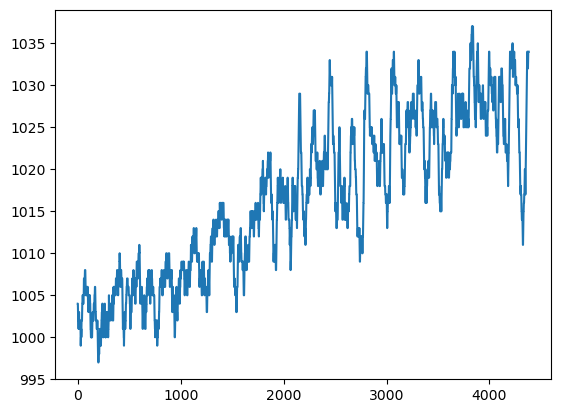

In [58]:
plt.plot(y_test)

In [59]:
X_val

array([[0.21818182, 0.21818182, 0.2       , ..., 0.2       , 0.2       ,
        0.2       ],
       [0.21818182, 0.2       , 0.21818182, ..., 0.2       , 0.2       ,
        0.18181818],
       [0.2       , 0.21818182, 0.2       , ..., 0.2       , 0.18181818,
        0.16363636],
       ...,
       [0.25454545, 0.23636364, 0.23636364, ..., 0.21818182, 0.21818182,
        0.23636364],
       [0.23636364, 0.23636364, 0.23636364, ..., 0.21818182, 0.23636364,
        0.23636364],
       [0.23636364, 0.23636364, 0.21818182, ..., 0.23636364, 0.23636364,
        0.23636364]], shape=(7887, 7))

In [60]:
y_val

array([1001., 1000., 1002., ..., 1004., 1004., 1004.], shape=(7887,))

In [61]:
import tensorflow.keras as keras

# Red Nueronal con una sola Capa oculta(MLP)
La siguiente es la configuración de una red neuronal con una sola capa oculta

In [62]:
model=keras.models.Sequential([keras.layers.Dense(64,activation="relu",input_shape=X_train.shape[1:]),keras.layers.Dense(1)])
model.summary()

/Users/sergiocalderonunal/opt/anaconda3/envs/NuevoAmbiente/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(loss="mean_squared_error",optimizer="adam")
history=model.fit(X_train,y_train,epochs=20,validation_data=(X_val,y_val)) #está tomando por defecto 32 del tamaño del lote, que sucede si es mayor o menor? Se puede modificar usando  el argumento batch_size= 

Epoch 1/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - loss: 871878.7500 - val_loss: 580320.5625
Epoch 2/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - loss: 322670.1875 - val_loss: 112958.5781
Epoch 3/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - loss: 97940.8438 - val_loss: 63719.8398
Epoch 4/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - loss: 78934.8438 - val_loss: 56793.3555
Epoch 5/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - loss: 67668.5078 - val_loss: 47131.1875
Epoch 6/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 611us/step - loss: 53388.3516 - val_loss: 35087.5117
Epoch 7/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 631us/step - loss: 37184.3438 - val_loss: 22351.7441
Epoch 8/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 620us/step - loss: 21118.5039 - val_loss: 10812.6064
Epoch 9/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - loss: 8514.7832 - val_loss: 3164.1670
Epoch 10/20
986/986 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - loss: 1870.1265 - val_loss: 340.4084
Epoch 11/20
986/986 ━━━━━━━━━━━━━━━━━━━━

In [64]:
31548/32

985.875

<Axes: >

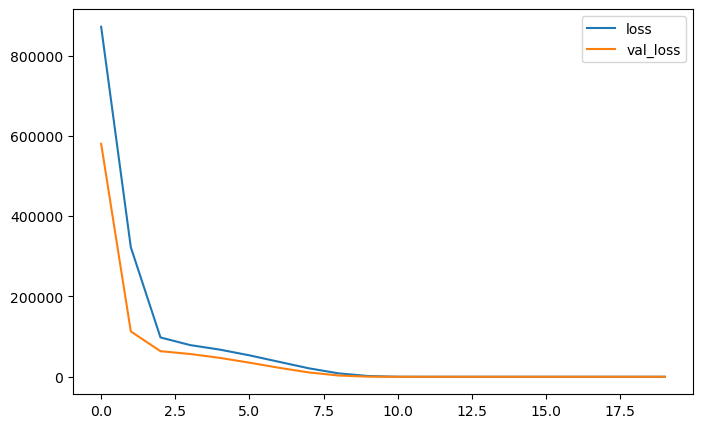

In [65]:
pd.DataFrame(history.history).plot(figsize=(8,5))

In [66]:
mse_test=model.evaluate(X_test,y_test)


137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - loss: 0.4685


In [67]:
print(mse_test)

0.46852603554725647


In [68]:
ypred=model.predict(X_test)
print(ypred)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step
[[1004.61566]
 [1004.4013 ]
 [1004.3322 ]
 ...
 [1034.1981 ]
 [1034.1237 ]
 [1033.9749 ]]


Text(0.5, 0, 'Index')

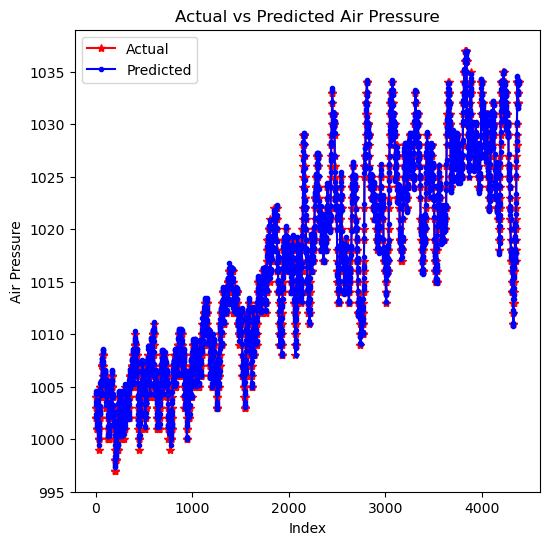

In [69]:
plt.figure(figsize=(6, 6))
plt.plot(range(y_test.size), y_test, linestyle='-', marker='*', color='r')
plt.plot(range(ypred.size), ypred, linestyle='-', marker='.', color='b') 
plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted Air Pressure')
plt.ylabel('Air Pressure')
plt.xlabel('Index')

Text(0.5, 0, 'Index')

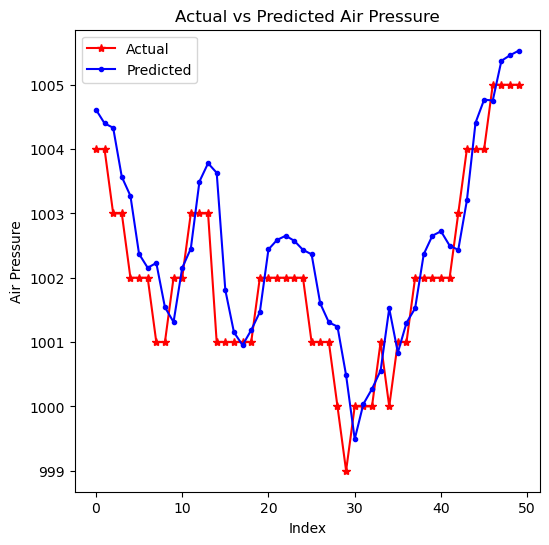

In [70]:
plt.figure(figsize=(6, 6))
plt.plot(range(50), y_test[0:50], linestyle='-', marker='*', color='r')
plt.plot(range(50), ypred[0:50], linestyle='-', marker='.', color='b') 
plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted Air Pressure')
plt.ylabel('Air Pressure')
plt.xlabel('Index')

# Modelos mas complejos

In [71]:
input_layer = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(32,activation="linear")(input_layer)
hidden2 = keras.layers.Dense(16,activation="linear")(hidden1)
hidden3 = keras.layers.Dense(16,activation="linear")(hidden2)
#dropout_layer = keras.layers.Dropout(0.2)(hidden3)
#output_layer = keras.layers.Dense(1, activation='linear')(dropout_layer)
output_layer = keras.layers.Dense(1, activation='linear')(hidden3)

In [72]:
ts_model=keras.Model(inputs=[input_layer],outputs=[output_layer])
ts_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073 (4.19 KB)

 Trainable params: 1,073 (4.19 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
print("Input shape:", X_train.shape)
print("Target shape:", y_train.shape)

Input shape: (31548, 7)
Target shape: (31548,)


In [74]:
type(X_train)

numpy.ndarray

In [75]:
ts_model.compile(loss="mean_squared_error",optimizer="adam")
history=ts_model.fit(X_train,y_train,epochs=20,batch_size=16,validation_data=(X_val,y_val))

Epoch 1/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 705us/step - loss: 101003.6562 - val_loss: 3.6882
Epoch 2/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 642us/step - loss: 2.9741 - val_loss: 2.2534
Epoch 3/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - loss: 1.7420 - val_loss: 1.3439
Epoch 4/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - loss: 1.2344 - val_loss: 1.1387
Epoch 5/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - loss: 1.0616 - val_loss: 2.1649
Epoch 6/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 2s 768us/step - loss: 1.1130 - val_loss: 0.6175
Epoch 7/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - loss: 1.0573 - val_loss: 0.5961
Epoch 8/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 2s 771us/step - loss: 0.9490 - val_loss: 0.8016
Epoch 9/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.9513 - val_loss: 1.7109
Epoch 10/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 698us/step - loss: 0.8238 - val_loss: 0.7304
Epoch 11/20
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 1s 661us/step - loss: 0.8788 - val_loss: 0.5929
Epoch

<Axes: >

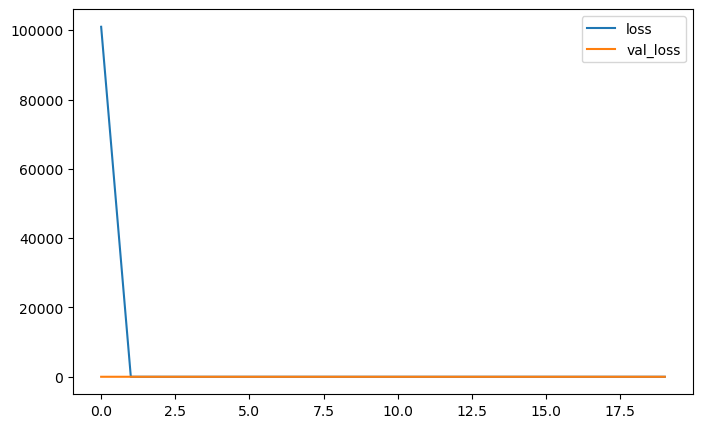

In [76]:
pd.DataFrame(history.history).plot(figsize=(8,5))

In [77]:
mse_test_multicapa=ts_model.evaluate(X_test,y_test)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 0.7115


In [78]:
print(mse_test)

0.46852603554725647


In [79]:
preds_ts_model=ts_model.predict(X_test)
print(preds_ts_model)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step
[[1004.6165]
 [1004.4456]
 [1004.4909]
 ...
 [1034.8696]
 [1034.6135]
 [1034.5225]]


Text(0.5, 0, 'Index')

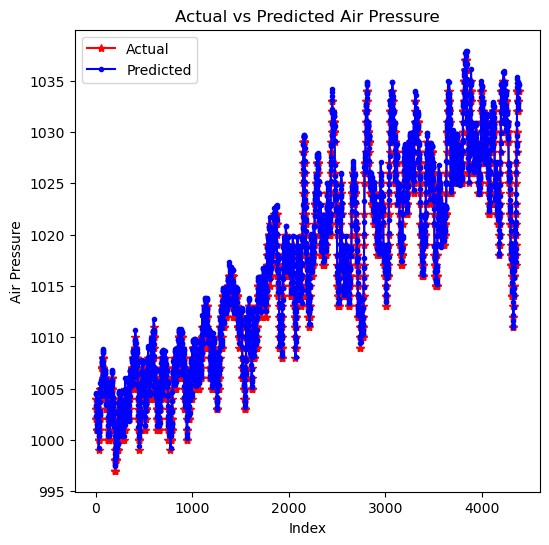

In [80]:
plt.figure(figsize=(6, 6))
plt.plot(range(y_test.size), y_test, linestyle='-', marker='*', color='r')
plt.plot(range(preds_ts_model.size), preds_ts_model, linestyle='-', marker='.', color='b') 
plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted Air Pressure')
plt.ylabel('Air Pressure')
plt.xlabel('Index')

Text(0.5, 0, 'Index')

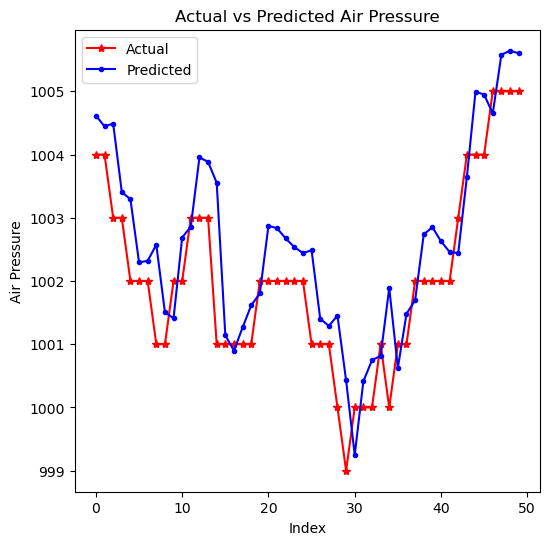

In [81]:
plt.figure(figsize=(6, 6))
plt.plot(range(50), y_test[0:50], linestyle='-', marker='*', color='r')
plt.plot(range(50), preds_ts_model[0:50], linestyle='-', marker='.', color='b') 
plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted Air Pressure')
plt.ylabel('Air Pressure')
plt.xlabel('Index')

# Busqueda de los hiperparámetros

In [82]:
from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers

E0000 00:00:1776775294.055287  758778 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1776775294.055802  758778 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1776775294.055809  758778 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1776775294.055811  758778 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1776775294.055814  758778 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


In [83]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Dense(units=hp.Int("num_units", min_value=32, max_value=64, step=32),
                activation=hp.Choice("activation", ["relu", "tanh"])))
    # Tune the number of layers.
    for i in range(hp.Int("num_layers", 1, 2)):
        model.add(
            layers.Dense(
                # Tune number of units separately.
                units=hp.Int(f"units_{i}", min_value=32, max_value=64, step=32),
                activation=hp.Choice("activation", ["relu", "tanh"]),
            )
        )
    if hp.Boolean("dropout"):
        model.add(layers.Dropout(rate=0.25))
    model.add(layers.Dense(1, activation="linear"))
    learning_rate = hp.Float("lr", min_value=1e-3, max_value=1e-2,step=0.006)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error",
        metrics=["mean_squared_error"]
    )
    return model


build_model(kt.HyperParameters())

<Sequential name=sequential_1, built=False>

In [84]:
tuner_GridSearch_mlp = kt.GridSearch(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=None,
    executions_per_trial=1,
    overwrite=True,
    directory="dirsalida",
    project_name="helloworld",
)

In [85]:
tuner_GridSearch_mlp.search_space_summary()

Search space summary
Default search space size: 6
num_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 64, 'step': 32, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh'], 'ordered': False}
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 64, 'step': 32, 'sampling': 'linear'}
dropout (Boolean)
{'default': False, 'conditions': []}
lr (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.001, 'max_value': 0.01, 'step': 0.006, 'sampling': 'linear'}


In [139]:
import keras_tuner as kt

def calculate_exact_grid_size(tuner):
    """
    Calcula el número exacto de combinaciones en un GridSearch
    recorriendo el árbol de hiperparámetros condicionales.
    """
    hp_space = tuner.oracle.hyperparameters

    def get_options(hp):
        config = hp.get_config()
        if isinstance(hp, kt.engine.hyperparameters.Int):
            return list(range(config['min_value'], config['max_value'] + 1, config['step']))
        elif isinstance(hp, kt.engine.hyperparameters.Choice):
            return config['values']
        elif isinstance(hp, kt.engine.hyperparameters.Boolean):
            return [True, False]
        elif isinstance(hp, kt.engine.hyperparameters.Float):
            # Nota: Esto es una simplificación para GridSearch con step definido
            import numpy as np
            return np.arange(config['min_value'], config['max_value'] + config['step']/2, config['step']).tolist()
        return [None]

    def explore(index, current_values):
        # Si hemos procesado todos los parámetros base registrados
        if index == len(hp_space.space):
            return 1
        
        hp = hp_space.space[index]
        
        # Verificar si este parámetro está activo dadas las condiciones actuales
        # (Keras Tuner maneja esto internamente, aquí simulamos el flujo)
        options = get_options(hp)
        total = 0
        
        for opt in options:
            # En un GridSearch real, si el parámetro no es aplicable en esta rama,
            # el Oráculo lo ignora. 
            total += explore(index + 1, {**current_values, hp.name: opt})
            
        return total

    # Keras Tuner GridSearch simplemente itera sobre el producto cartesiano 
    # de todos los parámetros registrados que 'podrían' aparecer.
    total_trials = 1
    print("--- Análisis del Espacio Dinámico ---")
    for hp in hp_space.space:
        config = hp.get_config()
        if isinstance(hp, kt.engine.hyperparameters.Int):
            n = int((config['max_value'] - config['min_value']) / config['step']) + 1
        elif isinstance(hp, kt.engine.hyperparameters.Choice):
            n = len(config['values'])
        elif isinstance(hp, kt.engine.hyperparameters.Boolean):
            n = 2
        elif isinstance(hp, kt.engine.hyperparameters.Float):
            n = int((config['max_value'] - config['min_value']) / config['step']) + 1
        else:
            n = 1
        
        print(f"{hp.name}: {n} opciones")
        # Para el GridSearch de Keras Tuner, si un parámetro es condicional,
        # se multiplica el espacio global por sus opciones.
        total_trials *= n

    return total_trials

# Nota: En tu caso particular, 2^6 (base) = 64.
# Al aparecer 'units_1' (2 opciones) SOLO cuando num_layers=2,
# El cálculo real para GridSearch es: (Combinaciones sin units_1) + (Combinaciones con units_1)
# Pero Keras Tuner GridSearch a menudo trata el espacio como el producto de todos los HPs 
# que han sido definidos globalmente en el oráculo.

real_total = calculate_exact_grid_size(tuner_GridSearch_mlp)
print(f"\nNúmero total de trials registrados: {real_total}")

--- Análisis del Espacio Dinámico ---
num_units: 2 opciones
activation: 2 opciones
num_layers: 2 opciones
units_0: 2 opciones
dropout: 2 opciones
lr: 2 opciones
units_1: 2 opciones

Número total de trials registrados: 128


In [87]:
stop_early=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=2)

In [88]:
tuner_GridSearch_mlp.search(X_train,y_train, epochs=10, validation_data=(X_val,y_val),callbacks=[stop_early])

Trial 120 Complete [00h 00m 11s]
val_loss: 120.90076446533203

Best val_loss So Far: 0.4137424826622009
Total elapsed time: 00h 17m 32s


In [89]:
X_val.shape

(7887, 7)

In [90]:
# Get the top 2 models.
models_mlp = tuner_GridSearch_mlp.get_best_models(num_models=2)
best_model_mlp = models_mlp[0]
# Build the model.
# Needed for `Sequential` without specified `input_shape`.
best_model_mlp.build(input_shape=(None, 7))
best_model_mlp.summary()

/Users/sergiocalderonunal/opt/anaconda3/envs/NuevoAmbiente/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,785 (26.50 KB)

 Trainable params: 6,785 (26.50 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
best_gs_mlp = tuner_GridSearch_mlp.get_best_hyperparameters(num_trials=1)[0]

print(f"""
La búsqueda ha terminado. El número óptimo de capas es {best_gs_mlp.get('num_layers')}, el de unidades en la capa es {best_gs_mlp.get('num_units')}, 
la mejor activación es {best_gs_mlp.get('activation')} y la mejor tasa de aprendizaje 
es {best_gs_mlp.get('lr')}.
""")


La búsqueda ha terminado. El número óptimo de capas es 2, el de unidades en la capa es 64, 
la mejor activación es relu y la mejor tasa de aprendizaje 
es 0.007.



# Los mejores 10 modelos



In [92]:
tuner_GridSearch_mlp.results_summary()

Results summary
Results in dirsalida/helloworld
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0082 summary
Hyperparameters:
num_units: 64
activation: relu
num_layers: 2
units_0: 64
dropout: False
lr: 0.007
units_1: 32
Score: 0.4137424826622009

Trial 0072 summary
Hyperparameters:
num_units: 64
activation: relu
num_layers: 2
units_0: 32
dropout: False
lr: 0.001
units_1: 32
Score: 0.43916255235671997

Trial 0057 summary
Hyperparameters:
num_units: 64
activation: relu
num_layers: 1
units_0: 32
dropout: False
lr: 0.001
units_1: 64
Score: 0.44473984837532043

Trial 0067 summary
Hyperparameters:
num_units: 64
activation: relu
num_layers: 1
units_0: 64
dropout: False
lr: 0.007
units_1: 64
Score: 0.4452766478061676

Trial 0005 summary
Hyperparameters:
num_units: 32
activation: relu
num_layers: 1
units_0: 64
dropout: False
lr: 0.007
Score: 0.45378410816192627

Trial 0074 summary
Hyperparameters:
num_units: 64
activation: relu
num_layers: 2
units_0: 32
dropout: False


# Ajuste del mejor modelo con el conjunto de entrenamineto y validación

In [93]:
x_all = np.concatenate((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

In [94]:
callback=tf.keras.callbacks.EarlyStopping(monitor="loss",patience=5)
best_hps_mlp = tuner_GridSearch_mlp.get_best_hyperparameters(2)
model_mlp = build_model(best_hps_mlp[0])
# Fit with the entire dataset.
model_mlp.fit(x_all,y_all, epochs=50,callbacks=[callback])

Epoch 1/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 2s 636us/step - loss: 32668.2188 - mean_squared_error: 32668.2188  
Epoch 2/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step - loss: 1.1239 - mean_squared_error: 1.1239
Epoch 3/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 625us/step - loss: 1.0005 - mean_squared_error: 1.0005
Epoch 4/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - loss: 1.0041 - mean_squared_error: 1.0041
Epoch 5/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - loss: 2.3856 - mean_squared_error: 2.3856
Epoch 6/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - loss: 5.4737 - mean_squared_error: 5.4737
Epoch 7/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 6.2993 - mean_squared_error: 6.2993
Epoch 8/50
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - loss: 6.1003 - mean_squared_error: 6.1003


In [95]:
model_mlp.layers[0].get_weights()[0]

array([[-0.04590495,  0.03080286, -0.1466286 ,  0.08473791, -0.05329813,
        -0.00148314, -0.27777448, -0.11499679,  0.00303349, -0.09191377,
         0.14503244, -0.14059438,  0.05892866, -0.00166454,  0.00173056,
        -0.21438475,  0.09809364,  0.12366455, -0.12440167, -0.15532146,
         0.22856142, -0.16659008,  0.1304227 ,  0.09378148,  0.08623769,
         0.01561689,  0.03097584,  0.06674376, -0.3269901 ,  0.0167604 ,
        -0.20656256, -0.15826204, -0.274144  , -0.18649837, -0.34733322,
        -0.4018796 ,  0.15191126, -0.21339202, -0.38771757, -0.13898367,
         0.02583185,  0.16092189,  0.01824012,  0.21662444, -0.3882643 ,
        -0.245236  ,  0.1397084 ,  0.24676971,  0.17139569, -0.02189515,
        -0.09720241, -0.18866044, -0.17511523,  0.04751967, -0.11296053,
        -0.29001263,  0.09372753, -0.082012  ,  0.05232016, -0.24753475,
        -0.09241714, -0.15332511, -0.27635664, -0.28389367],
       [-0.28712383,  0.23559675, -0.26751047,  0.12949015,  0.

In [96]:
print(model_mlp.layers[0].bias.numpy())

[-0.04203824  0.78599477 -0.11353967  0.84928536  0.797294    0.
 -0.03588225  0.8758451   0.81754285  0.8190375   0.86947286  0.
  0.8694992   0.82805526 -0.15992603 -0.03608933  0.80129015  0.8402096
  0.88405234  0.88533837 -0.0358125  -0.16529928  0.8382343   0.81340295
  0.7937102  -0.04731559 -0.03608932  0.8663754  -0.11924122  0.883801
 -0.07590744 -0.08163276  0.87845415  0.          0.87623405 -0.15856509
  0.85403764  0.         -0.11385225  0.90096456  0.          0.9283058
 -0.04157568  0.8536463  -0.15856525 -0.03588373  0.          0.86655617
  0.8043843   0.8612579   0.          0.9386727   0.          0.8784227
  0.         -0.08506679  0.74377024  0.86177194  0.88452387 -0.03588374
  0.          0.8071132   0.          0.        ]


In [97]:
X_test.shape

(4382, 7)

In [98]:
prediction_test=model_mlp.predict( X_test, verbose=1)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step


In [99]:
prediction_test

array([[1004.1577 ],
       [1004.1028 ],
       [1004.07385],
       ...,
       [1034.3306 ],
       [1034.3345 ],
       [1033.966  ]], shape=(4382, 1), dtype=float32)

In [100]:
y_test=y_test.reshape((y_test.shape[0], 1))

In [101]:
prediction_test.shape

(4382, 1)

In [102]:
print(prediction_test)

[[1004.1577 ]
 [1004.1028 ]
 [1004.07385]
 ...
 [1034.3306 ]
 [1034.3345 ]
 [1033.966  ]]


In [103]:
y_test.shape

(4382, 1)

In [104]:
print(y_test)

[[1004.]
 [1004.]
 [1003.]
 ...
 [1034.]
 [1034.]
 [1034.]]


In [105]:
mse_metric = tf.keras.metrics.MeanSquaredError()
mse_metric.update_state(y_test, prediction_test)
final_mse = mse_metric.result().numpy()
print(f"Mean Squared Error: {final_mse}")


Mean Squared Error: 0.4077201783657074


# Gráfica en el conjunto de prueba

Text(0, 0.5, 'Y y $\\hat{Y}$ en conjunto de prueba')

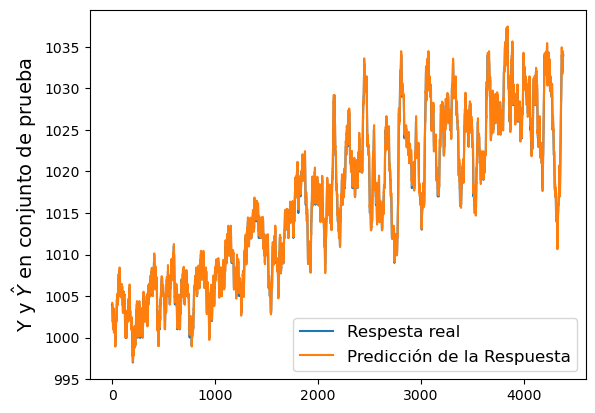

In [106]:
plt.plot(y_test)
plt.plot(prediction_test)
plt.legend(['Respesta real','Predicción de la Respuesta'],loc="best", fontsize=12)
plt.ylabel('Y y $\hat{Y}$ en conjunto de prueba', fontsize=14)

Text(0, 0.5, '$\\hat{e}$ en conjunto de prueba')

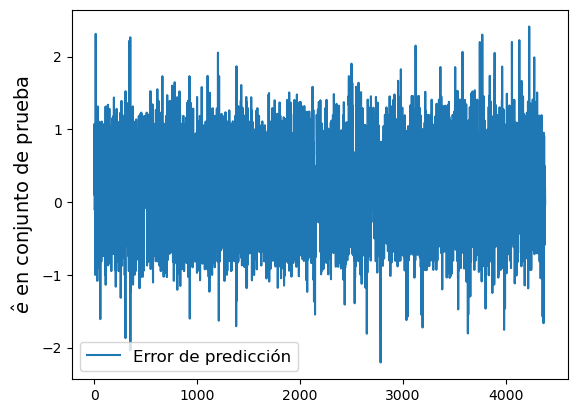

In [107]:
plt.plot(prediction_test-y_test)
plt.legend(['Error de predicción'],loc="best", fontsize=12)
plt.ylabel('$\hat{e}$ en conjunto de prueba', fontsize=14)

In [108]:
prediction_test-y_test

array([[ 0.15771484],
       [ 0.1027832 ],
       [ 1.07385254],
       ...,
       [ 0.33056641],
       [ 0.33447266],
       [-0.03405762]], shape=(4382, 1))

## Modelo con Redes LSTM (Long Short-Term Memory)

Las redes LSTM son un tipo de Red Neuronal Recurrente (RNN) capaz de aprender dependencias a largo plazo, lo cual es ideal para series de tiempo.

In [109]:
import numpy as np

# 1. Remodelar los datos para LSTM: [samples, time_steps, features]
# Usaremos los 7 retardos (lags) como pasos de tiempo de una sola característica
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_lstm = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Nueva forma de entrenamiento: {X_train_lstm.shape}")

Nueva forma de entrenamiento: (31548, 7, 1)


In [110]:
X_train_lstm

array([[[0.54545455],
        [0.52727273],
        [0.50909091],
        ...,
        [0.49090909],
        [0.47272727],
        [0.47272727]],

       [[0.52727273],
        [0.50909091],
        [0.50909091],
        ...,
        [0.47272727],
        [0.47272727],
        [0.47272727]],

       [[0.50909091],
        [0.50909091],
        [0.49090909],
        ...,
        [0.47272727],
        [0.47272727],
        [0.47272727]],

       ...,

       [[0.21818182],
        [0.2       ],
        [0.21818182],
        ...,
        [0.21818182],
        [0.2       ],
        [0.21818182]],

       [[0.2       ],
        [0.21818182],
        [0.21818182],
        ...,
        [0.2       ],
        [0.21818182],
        [0.2       ]],

       [[0.21818182],
        [0.21818182],
        [0.21818182],
        ...,
        [0.21818182],
        [0.2       ],
        [0.2       ]]], shape=(31548, 7, 1))

In [121]:
X_train_lstm.shape[1]

7

In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 2. Definir el modelo LSTM
model_lstm = Sequential([
    LSTM(50, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [127]:
history_lstm = model_lstm.fit(
    X_train_lstm, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_lstm, y_val),
    verbose=1
)

Epoch 1/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 122113.3750 - val_loss: 8.3965
Epoch 2/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.3558 - val_loss: 7.2876
Epoch 3/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.6949 - val_loss: 7.1339
Epoch 4/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.2936 - val_loss: 7.9573
Epoch 5/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.6505 - val_loss: 5.8450
Epoch 6/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.2146 - val_loss: 5.7649
Epoch 7/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.0998 - val_loss: 6.0954
Epoch 8/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5501 - val_loss: 9.3761
Epoch 9/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.9335 - val_loss: 6.5318
Epoch 10/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.8204 - val_loss: 7.5191
Epoch 11/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.0733 - val_loss: 7.2849
Epoch 12/50
986/986 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


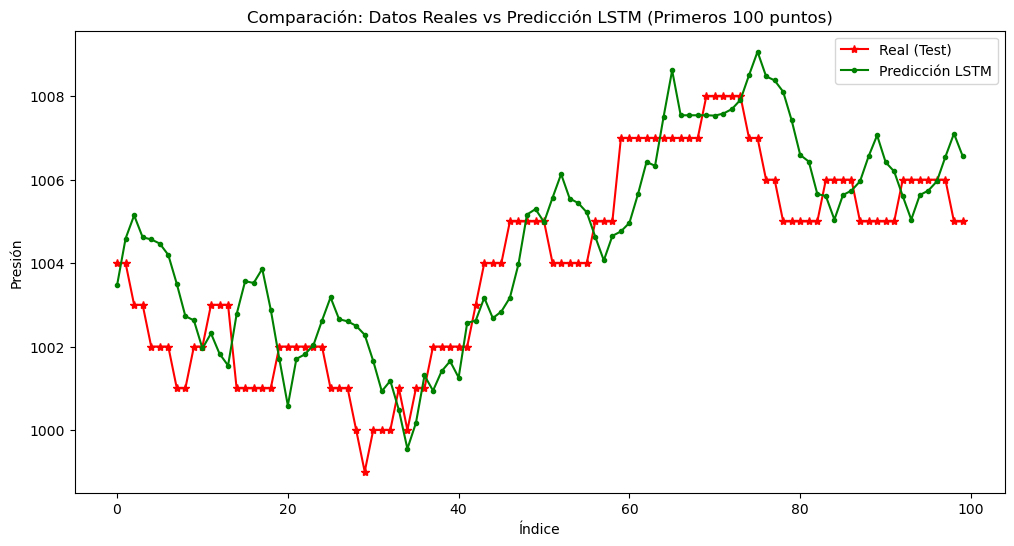

In [128]:
# 4. Evaluación y Visualización
ypred_lstm = model_lstm.predict(X_test_lstm)

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100], label='Real (Test)', color='red', marker='*')
plt.plot(ypred_lstm[:100], label='Predicción LSTM', color='green', marker='.')
plt.title('Comparación: Datos Reales vs Predicción LSTM (Primeros 100 puntos)')
plt.xlabel('Índice')
plt.ylabel('Presión')
plt.legend()
plt.show()



In [132]:
print(X_test_lstm.shape)

print(y_test.shape)

print(type(X_test_lstm))

print(type(y_test))
model_lstm.summary()

(4382, 7, 1)
(4382, 1)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

In [133]:
y_pred = model_lstm.predict(X_test_lstm)

print(y_pred.shape)
print(y_test.shape)

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step
(4382, 1)
(4382, 1)


In [134]:
from sklearn.metrics import mean_squared_error

final_mse_lstm = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error LSTM: {final_mse_lstm}")

Mean Squared Error LSTM: 3.0704218227780133


In [135]:
# Crear un resumen de los resultados de test
resumen_resultados = pd.DataFrame({
    'Modelo': ['MLP Una Capa', 'MLP Multicapa', 'LSTM'],
    'MSE Test': [mse_test, mse_test_multicapa, final_mse_lstm]
})

display(resumen_resultados)

,Modelo,MSE Test
0,MLP Una Capa,0.468526
1,MLP Multicapa,0.711464
2,LSTM,3.070422


## Búsqueda de Hiperparámetros para LSTM usando Hyperband

In [136]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

def build_lstm_model(hp):
    model = keras.Sequential()
    # Ajustar el número de unidades en la capa LSTM
    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    # Ajustar la función de activación
    hp_activation = hp.Choice('activation', values=['relu', 'tanh'])

    model.add(layers.LSTM(units=hp_units,
                         activation=hp_activation,
                         input_shape=(X_train_lstm.shape[1], 1)))
    model.add(layers.Dense(1))

    # Ajustar la tasa de aprendizaje
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mse'])

    return model

# Configurar el sintonizador Hyperband
tuner_hyperband_lstm = kt.Hyperband(
    build_lstm_model,
    objective='val_loss',
    max_epochs=20,
    factor=3,
    directory='dir_tuning_lstm',
    project_name='lstm_hyperband'
)

# Callback para detenerse si el modelo no mejora
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)



Reloading Tuner from dir_tuning_lstm/lstm_hyperband/tuner0.json


In [137]:
# Iniciar la búsqueda
tuner_hyperband_lstm.search(X_train_lstm, y_train,
                            epochs=20,
                            validation_data=(X_val_lstm, y_val),
                            callbacks=[stop_early])

In [138]:
best_hps_lstm = tuner_hyperband_lstm.get_best_hyperparameters(num_trials=1)[0]

print(f"""
La búsqueda ha terminado. El número óptimo de unidades en la capa LSTM es {best_hps_lstm.get('units')}, 
la mejor activación es {best_hps_lstm.get('activation')} y la mejor tasa de aprendizaje 
es {best_hps_lstm.get('learning_rate')}.
""")


La búsqueda ha terminado. El número óptimo de unidades en la capa LSTM es 64, 
la mejor activación es relu y la mejor tasa de aprendizaje 
es 0.0001.

